# Avaliação do Modelo MoE-DQN para SOR

Comparação entre a estratégia baseline TWAP e o agente de IA MoE-DQN na execução de ordens entre B3 e Base, com análise de preço médio e economia gerada.

In [6]:
# Configuração de caminho para importar o pacote local `src`
import sys
from pathlib import Path

ROOT_DIR = Path('..').resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt

# Importando as classes e funções de avaliação
from src.sor_env import MultiVenueSOREnv
from src.moe_dqn import MoENetwork
from src.evaluate_baselines import simulate_twap, evaluate_agent

plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
import os
import random
import numpy as np
import torch

def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

def assert_env_info_keys(info: dict) -> None:
    required = {
        "inventory_left", "arrival_price",
        "executed_cost", "executed_volume",
        "avg_price", "slippage", "is_valid", "rejection_reason",
        "t", "T",
    }
    missing = required - set(info.keys())
    if missing:
        raise RuntimeError(f"Env.step() não está retornando info auditável. Faltam: {missing}")

### Geração de Dados de Teste (Out of Sample)

In [8]:
steps = 500
np.random.seed(99) # Semente diferente da usada no treinamento

df_b3 = pd.DataFrame({
    'ask_1': np.random.uniform(47.05, 47.15, steps), 'vol_ask_1': np.random.randint(100, 500, steps),
    'ask_2': np.random.uniform(47.16, 47.25, steps), 'vol_ask_2': np.random.randint(100, 500, steps),
    'ask_3': np.random.uniform(47.26, 47.35, steps), 'vol_ask_3': np.random.randint(100, 500, steps),
    'ask_4': np.random.uniform(47.36, 47.45, steps), 'vol_ask_4': np.random.randint(100, 500, steps),
    'ask_5': np.random.uniform(47.46, 47.55, steps), 'vol_ask_5': np.random.randint(100, 500, steps),
})

df_base = pd.DataFrame({
    'ask_1': np.random.uniform(47.00, 47.10, steps), 'vol_ask_1': np.random.randint(50, 300, steps),
    'ask_2': np.random.uniform(47.11, 47.20, steps), 'vol_ask_2': np.random.randint(50, 300, steps),
    'ask_3': np.random.uniform(47.21, 47.30, steps), 'vol_ask_3': np.random.randint(50, 300, steps),
    'ask_4': np.random.uniform(47.31, 47.40, steps), 'vol_ask_4': np.random.randint(50, 300, steps),
    'ask_5': np.random.uniform(47.41, 47.50, steps), 'vol_ask_5': np.random.randint(50, 300, steps),
})

print("Dados de teste gerados com sucesso.")

Dados de teste gerados com sucesso.


### Carregando o Modelo e Executando a Comparação

In [9]:
TOTAL_ORDER = 10000
env_twap = MultiVenueSOREnv(lob_b3=df_b3, lob_base=df_base, total_inventory=TOTAL_ORDER)
env_ia   = MultiVenueSOREnv(lob_b3=df_b3, lob_base=df_base, total_inventory=TOTAL_ORDER)

caminho_modelo = ROOT_DIR / 'models' / 'moe_dqn_sor.pth'
agente_treinado = MoENetwork(input_dim=5, output_dim=4, num_experts=3)
agente_treinado.load_state_dict(torch.load(caminho_modelo, map_location="cpu"))
agente_treinado.eval()

# Use as mesmas funções auditáveis do notebook 01
preco_twap, vol_twap, stats_twap = simulate_twap(env_twap, TOTAL_ORDER)
preco_ia, vol_ia, stats_ia = evaluate_agent(agente_treinado, env_ia)

arrival = env_ia.arrival_price
print("\n--- RESULTADOS FINAIS (AUDITÁVEIS) ---")
print(f"Arrival: R$ {arrival:.4f}")
avg_twap = stats_twap.get("avg_price", preco_twap)
avg_ia = stats_ia.get("avg_price", preco_ia)

# Garante compatibilidade com as linhas abaixo (evita KeyError)
stats_twap["avg_price"] = avg_twap
stats_ia["avg_price"] = avg_ia

print(f"TWAP -> avg_price: R$ {avg_twap:.4f} | IS/share: R$ {avg_twap - arrival:.6f}")
print(f"IA   -> avg_price: R$ {stats_ia['avg_price']:.4f} | IS/share: R$ {stats_ia['avg_price'] - arrival:.6f}")

economia_total = (stats_twap["avg_price"] - stats_ia["avg_price"]) * TOTAL_ORDER
print(f"Economia total (R$): {economia_total:.2f}")


--- RESULTADOS FINAIS (AUDITÁVEIS) ---
Arrival: R$ 47.0190
TWAP -> avg_price: R$ 47.0592 | IS/share: R$ 0.040190
IA   -> avg_price: R$ 47.0340 | IS/share: R$ 0.014947
Economia total (R$): 252.43


### Gerando os Gráficos Finais

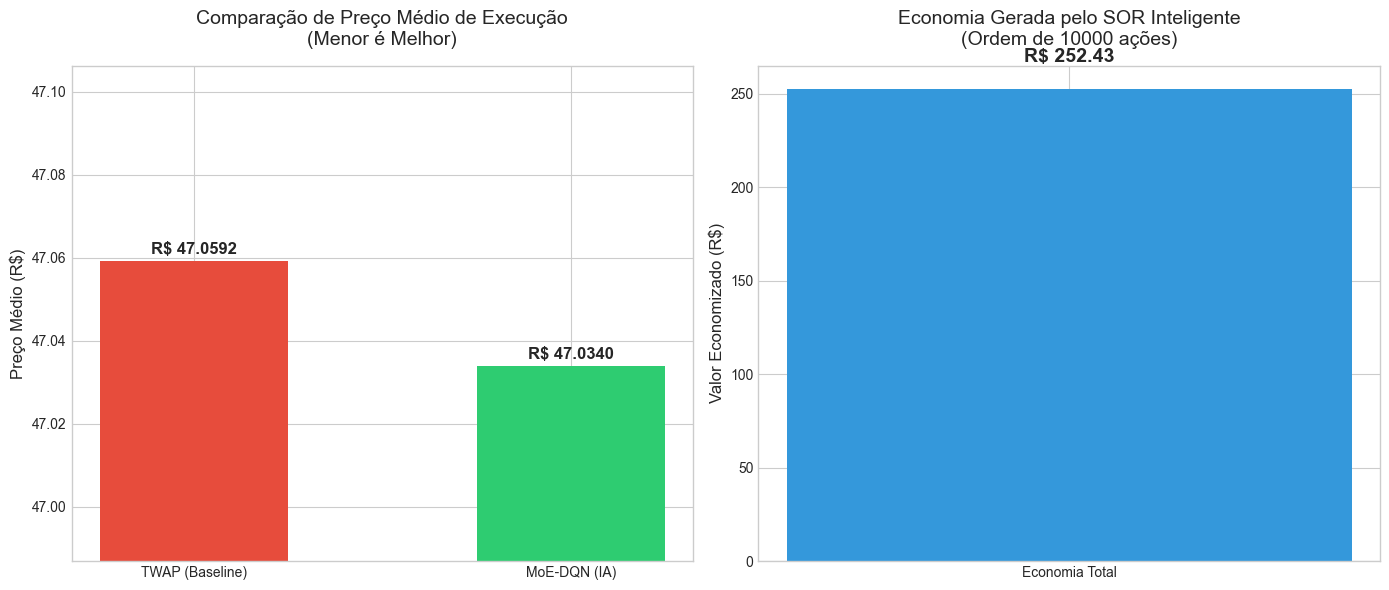

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Comparação de Preço Médio (Slippage)
modelos = ['TWAP (Baseline)', 'MoE-DQN (IA)']
precos = [preco_twap, preco_ia]
cores = ['#e74c3c', '#2ecc71']

bars = ax1.bar(modelos, precos, color=cores, width=0.5)
ax1.set_title('Comparação de Preço Médio de Execução\n(Menor é Melhor)', fontsize=14, pad=15)
ax1.set_ylabel('Preço Médio (R$)', fontsize=12)
ax1.set_ylim(min(precos) * 0.999, max(precos) * 1.001)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'R$ {yval:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Gráfico 2: Economia Total Gerada
economia_por_acao = preco_twap - preco_ia
economia_total = economia_por_acao * TOTAL_ORDER

ax2.bar(['Economia Total'], [economia_total], color='#3498db', width=0.3)
ax2.set_title(f'Economia Gerada pelo SOR Inteligente\n(Ordem de {TOTAL_ORDER} ações)', fontsize=14, pad=15)
ax2.set_ylabel('Valor Economizado (R$)', fontsize=12)
ax2.text(0, economia_total + (abs(economia_total)*0.05), f'R$ {economia_total:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()